In [1]:
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
import pandas as pd
import itertools
from Bio import AlignIO
import numpy as np
import re

# Path to your Foldmason MSTA file
msta_file = "msta_aa.fa"  
# Path to your lDDT file (extracted from Foldmason)
lddt_file = "col_lddt.txt"  
# Read lddt file and extract the lDDT scores
with open(lddt_file, 'r') as f:
    line = f.readline().strip()  # Read the first line and remove whitespace
    scores_str = line.split(":", 1)[1].strip(" []")
# Convert extracted values to float, ignoring empty values
lddt_scores = [float(x) for x in scores_str.split(',') if x.strip()]
#remove -1s (where one or less proteins aligned in column)
valid_scores = [(i, s) for i, s in enumerate(lddt_scores) if s != -1]
values = [s for _, s in valid_scores]

#lDDT threshold when 0 > n of proteins in MSTA <= 25
Q50_threshold = np.median(values)
#lDDT threshold when 25 > n of proteins in MSTA <= 200
Q75_threshold = np.percentile(values, 75)
#lDDT threshold when n of proteins in MSTA > 200
Q90_threshold = np.percentile(values, 90)

# Select high-lDDT columns
high_lddt_positions = [
    (i, s) for i, s in valid_scores
    if s >= Q50_threshold #adjust threshold as necessary
]

high_lddt_indices = [i for i, _ in high_lddt_positions]

# Extract positions from high lDDT list
high_lddt_indices = [pos for pos, score in high_lddt_positions]
#print(high_lddt_indices)

# Step 2: Load the MSA file
alignment = AlignIO.read(msta_file, "fasta")  
msta_array = np.array([list(record.seq) for record in alignment], dtype=str)

# Use extracted indices to select columns in the MSA array
selected_columns = msta_array[:, high_lddt_indices]

# Extract the high-lDDT sequences
high_lddt_sequences = ["".join(selected_columns[i, :]) for i in range(msta_array.shape[0])]

# Create SeqRecord objects for each sequence
records = []
for i, record in enumerate(alignment):
    new_seq = Seq(high_lddt_sequences[i])  
    new_record = SeqRecord(new_seq, id=record.id)
    records.append(new_record)

# Save to a new FASTA file 
output_fasta_path = "high_lddt_sequences.fa"
with open(output_fasta_path, "w") as output_file:
    SeqIO.write(records, output_file, "fasta")

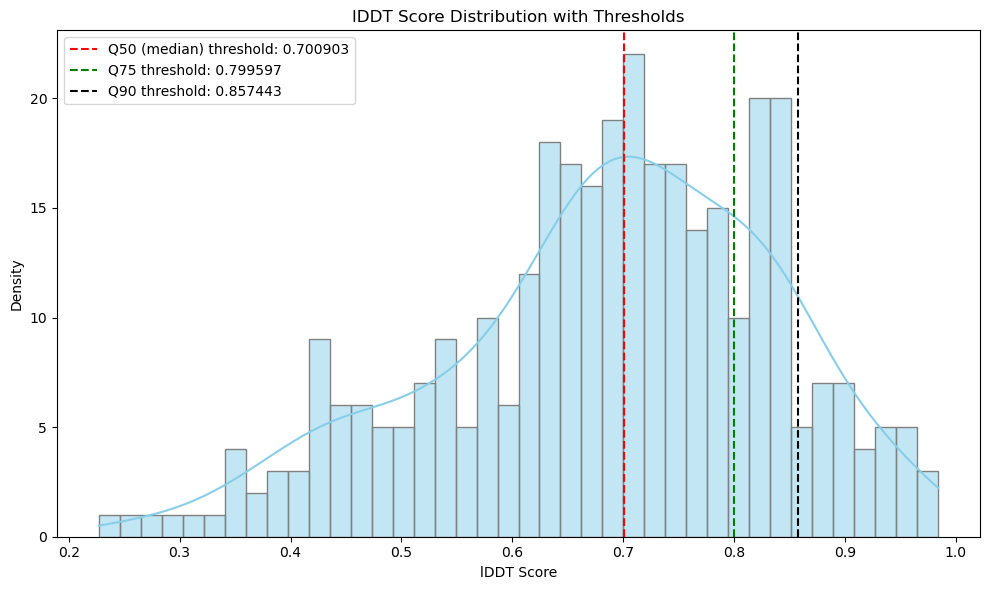

In [2]:
#if necessary inspect the lddt score distribution in the MSTA and plot high-lddt thresholds

from scipy.stats import gaussian_kde
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

with open("col_lddt.txt", 'r') as f:
    line = f.readline().strip()

scores_str = line.split(":", 1)[1].strip(" []")
lddt_scores = [float(x) for x in scores_str.split(',') if x.strip()]
lddt_scores = [x for x in lddt_scores if x != -1]

lddt_array = np.array(lddt_scores)

plt.figure(figsize=(10, 6))
sns.histplot(lddt_scores, bins=40, kde=True, color='skyblue', edgecolor='gray')
plt.axvline(Q50_threshold, color='red', linestyle='--', label=f'Q50 (median) threshold: {Q50_threshold:.6f}')
plt.axvline(Q75_threshold, color='green', linestyle='--', label=f'Q75 threshold: {Q75_threshold:.6f}')
plt.axvline(Q90_threshold, color='black', linestyle='--', label=f'Q90 threshold: {Q90_threshold:.6f}')

plt.title("lDDT Score Distribution with Thresholds")
plt.xlabel("lDDT Score")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


In [3]:
import os
import subprocess
from Bio import PDB
from Bio import AlignIO

# msta file path
msta_file = "msta_aa.fa"  
#path to pdb files in msta
pdb_folder = "."
#output directory for high-lDDT ARP structures
output_folder = "high_lddt_subjects/"
pdb_files = [f for f in os.listdir(pdb_folder) if f.endswith('.pdb')]

#Map Aligned Indices to Original Residue Positions 
def map_alignment_to_original(msta_file, aligned_indices):

    alignment = AlignIO.read(msta_file, "fasta")  # Load alignment
    mapping_results = {}

    for record in alignment:
        seq_id = record.id
        aligned_seq = str(record.seq) 

        original_positions = []  
        residue_counter = 0 

        for i, char in enumerate(aligned_seq):
            if char != "-":  #ignore gaps
                residue_counter += 1
            if i in aligned_indices:
                if char != "-":
                    original_positions.append(residue_counter)

        mapping_results[seq_id] = original_positions

    return mapping_results

#use high_lddt_indices - list of indices with high lDDT values
mapped_positions = map_alignment_to_original(msta_file, high_lddt_indices)

#print to check
print("Mapped Positions:", mapped_positions)

def extract_high_lddt_residues(pdb_file, residue_positions, output_pdb):
    """
    Extracts specified residue positions from a PDB file and writes them to a new PDB file.
    param pdb_file: Path to input PDB file
    param residue_positions: List of residue indices to extract
    param output_pdb: Path to output PDB file
    """
    parser = PDB.PDBParser(QUIET=True)
    structure = parser.get_structure("protein", pdb_file)
    output_pdb
    io = PDB.PDBIO()
    io.set_structure(structure)

    class SelectResidues(PDB.Select):
        def accept_residue(self, residue):
            res_id = residue.get_id()[1]  # Residue sequence number
            return res_id in residue_positions  # Keep only selected residues

    io.save(output_pdb, select=SelectResidues())
    print(f"Extracted high-lDDT residues saved to {output_pdb}")

#extract high-lDDT residues for all proteins
for pdb_file in pdb_files:
    pdb_id = os.path.splitext(pdb_file)[0] 

    if pdb_id in mapped_positions:  
        print(f"Processing: {pdb_file}")
        residue_positions = mapped_positions[pdb_id]
        input_pdb = os.path.join(pdb_folder, pdb_file)
        output_pdb = os.path.join(output_folder, f"{pdb_id}_Q50_lddt.pdb") #adjust to Q50_lddt/Q75_lddt/Q90_lddt as necessary
        extract_high_lddt_residues(input_pdb, residue_positions, output_pdb)
    else:
        print(f"Warning: No mapped positions found for {pdb_file}")


Mapped Positions: {'AF-A0A854E766-F1-model_v4': [7, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 64, 67, 68, 69, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 134, 135, 136, 137, 142, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 188, 189, 194, 195, 196, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 215, 216, 217, 218, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 249, 250, 251, 252, 253, 254, 266, 273, 274, 275, 276, 277, 278, 280, 281, 282, 284, 285, 286, 314, 315, 316, 317, 318, 319, 320, 321, 322, 330, 331], 'O06916': [9, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 66, 